## Welcome to the basic neural network tutorial!
The following notebook is designed to walk through the process of building and training your first scikit based algorithm using the standalone MaCh3 python utilities!

If you're writing scripts this is encapsulate in the objects in `MaCh3PythonUtils/config_reader` however this guide aims to break apart the process of writing the code for yourself!

The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory

# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import seaborn as sns
import pandas as pd
import gdown

Using mps device

In [2]:


file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"


path_2= Path("../models/chain_files_2/")
path_4= Path('../models/chain_files_4/')
path_8= Path('../models/chain_files_8/')
path_16= Path('../models/chain_files_16/')

pathlist2=[f"{path_2}/{x}" for x in os.listdir(path_2)] 
pathlist4=[f'{path_4}/{y}' for y in os.listdir(path_4)]
pathlist8=[f'{path_8}/{z}' for z in os.listdir(path_8)]
pathlist16=[f'{path_16}/{a}' for a in os.listdir(path_16)]

paths = (pathlist2, pathlist4, pathlist8, pathlist16)

fitting_label = "ID"

# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]
chain_list_2 = []
chain_list_4 = []
chain_list_8 = []
chain_list_16 = []

for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
            # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19"])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
            #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
            # chain_handler.add_additional_plots(fitting_label, True)

            # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

            # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == pathlist2:
            chain_list_2.append(chain_handler)
            print(chain_handler, '-> chain_list_2')
        elif lm == pathlist4:
            chain_list_4.append(chain_handler)
            print(chain_handler, '-> chain_list_4')
        elif lm == pathlist8:
            chain_list_8.append(chain_handler)
            print(chain_handler, '-> chain_list_8')
        elif lm == pathlist16:
            chain_list_16.append(chain_handler)
            print(chain_handler, '-> chain_list_16')


main_chain2 = chain_list_2[0]
main_chain2.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

main_chain4 = chain_list_4[0]
main_chain4.ttree_array['ID']= 0

main_chain8 = chain_list_8[0]
main_chain8.ttree_array['ID']= 0

main_chain16 = chain_list_16[0]
main_chain16.ttree_array['ID']= 0


for id, chain in enumerate(chain_list_2[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
    main_chain2.ttree_array = pd.concat([main_chain2.ttree_array, chain.ttree_array])

for ida, chains in enumerate(chain_list_4[1:], start = 1): 
    #add ID to chain['id']
    chains.ttree_array['ID'] = ida
    chains.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chains.ttree_array))*1.2
    main_chain4.ttree_array = pd.concat([main_chain4.ttree_array, chains.ttree_array])

for idb, chainss in enumerate(chain_list_8[1:], start = 1): 
    #add ID to chain['id']
    chainss.ttree_array['ID'] = idb
    chainss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainss.ttree_array))*1.2
    main_chain8.ttree_array = pd.concat([main_chain8.ttree_array, chainss.ttree_array])

for idc, chainsss in enumerate(chain_list_16[1:], start = 1): 
    #add ID to chain['id']
    chainsss.ttree_array['ID'] = idc
    chainsss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainsss.ttree_array))*1.2
    main_chain16.ttree_array = pd.concat([main_chain16.ttree_array, chainsss.ttree_array])






print(f'FINAL Framework: {main_chain4.ttree_array}')
'''
print(f'FINAL Framework: {main_chain4.ttree_array}')
print(f'FINAL Framework: {main_chain8.ttree_array}')
print(f'FINAL Framework: {main_chain16.ttree_array}')
'''




Attempting to open ../models/chain_files_2/demo_chain.root
Succesfully opened ../models/chain_files_2/demo_chain.root:posteriors
Using 12 threads and requiring 0.032 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> xsec_6
  -> xsec_7
  -> xsec_8
  -> xsec_9
  -> xsec_10
  -> xsec_11
  -> xsec_12
  -> xsec_13
  -> xsec_14
  -> xsec_15
  -> xsec_16
  -> xsec_17
  -> xsec_18
  -> xsec_21
  -> xsec_22
Converted TTree to pandas dataframe with 30304 elements
<MaCh3PythonUtils.file_handling.chain_handler.ChainHandler object at 0x1786b7810> -> chain_list_2
Attempting to open ../models/chain_files_2/demo_chain2.root
Succesfully opened ../models/chain_files_2/demo_chain2.root:posteriors
Using 12 threads and requiring 0.032 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> xsec_6
  -> xsec_7
  -> xsec_8
  -> xsec_9
  -> xsec_10
  -> xsec_11
  -> xsec_12
  -> xse

"\nprint(f'FINAL Framework: {main_chain4.ttree_array}')\nprint(f'FINAL Framework: {main_chain8.ttree_array}')\nprint(f'FINAL Framework: {main_chain16.ttree_array}')\n"

## Machine learning
Okay now we've done some very basic file manipulation, it's time for some machine learning!
All algorithms use the same common `MLFactory` interface so let's go about configuring it!

In [3]:
# First step we need to initialise the factory
from pathlib import Path

model_output=Path("../models/chain_files_2/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory2 = MLFactory(main_chain2, fitting_label, f"{model_output}.pdf")


model_output2=Path("../models/chain_files_4/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory4 = MLFactory(main_chain4, fitting_label, f"{model_output}.pdf")



model_output3=Path("../models/chain_files_8/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory8 = MLFactory(main_chain8, fitting_label, f"{model_output}.pdf")


model_output4=Path("../models/chain_files_16/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory16 = MLFactory(main_chain16, fitting_label, f"{model_output}.pdf")



ID
ID
ID
ID


Now we need to define a model, for this demonstration we'll make a very simple BDT!

In [4]:
# Now we can make the model
ml_model2 = ml_factory2.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model2.set_training_test_set(0.3)

ml_model4 = ml_factory4.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model4.set_training_test_set(0.3)

ml_model8 = ml_factory8.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model8.set_training_test_set(0.3)

ml_model16 = ml_factory16.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model16.set_training_test_set(0.3)


In [5]:
# Now we need to train our network
ml_model2.train_model()

ml_model4.train_model()

ml_model8.train_model()
#ml_model16.train_model()


Training Model
Binning 0.006 GB of training data: 0.108 s
Binning 0.001 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 176 trees in 7.957 s, (44000 total leaves)
Time spent computing histograms: 2.879s
Time spent finding best splits:  1.783s
Time spent applying splits:      2.320s
Time spent predicting:           0.022s
Training Model
Binning 0.013 GB of training data: 0.061 s
Binning 0.001 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 368 trees in 20.830 s, (91088 total leaves)
Time spent computing histograms: 8.036s
Time spent finding best splits:  4.893s
Time spent applying splits:      5.958s
Time spent predicting:           0.067s
Training Model
Binning 0.026 GB of training data: 0.130 s
Binning 0.003 GB of validation data: 0.004 s
Fitting gradient boosted rounds:
Fit 1208 trees in 80.202 s, (302000 total leaves)
Time spent computing histograms: 31.429s
Time spent finding best splits:  18.754s
Time spent applying splits:      22.211s
Time

Number of independent MCMCs: 2

Training Results!

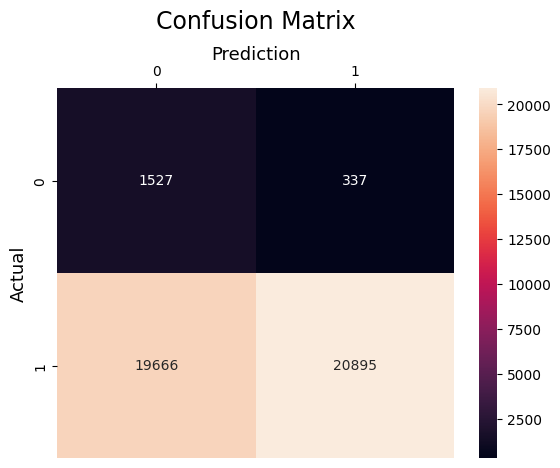

[[ 1527   337]
 [19666 20895]]

predictive accuracy: 0.5285091337654685

R*: 1.057018267530937

=====

Testing Results!

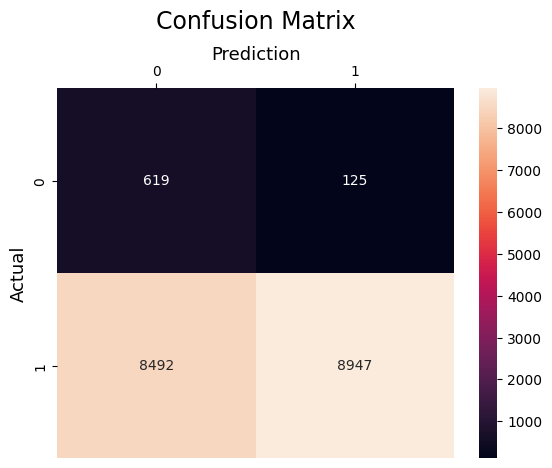

[[ 619  125]
 [8492 8947]]

predictive accuracy: 0.5260958037727548

R*: 1.0521916075455096

=====

Training Model

...

=====

Testing Results!

=====

Number of independent MCMCs: 4

Training Results!

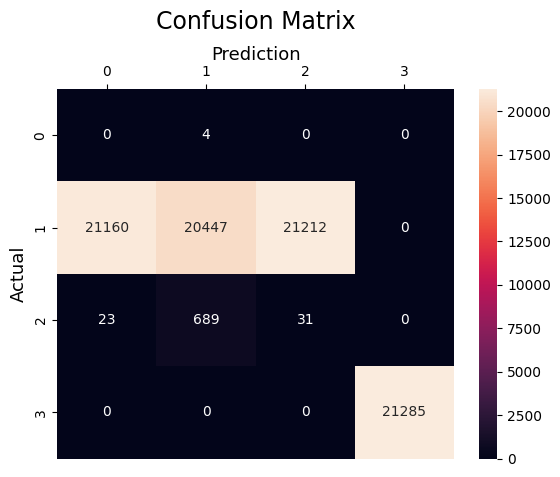

[[    0     4     0     0]
 [21160 20447 21212     0]
 [   23   689    31     0]
 [    0     0     0 21285]]

predictive accuracy: 0.4921921957313408

R*: 1.9687687829253633

=====

Testing Results!

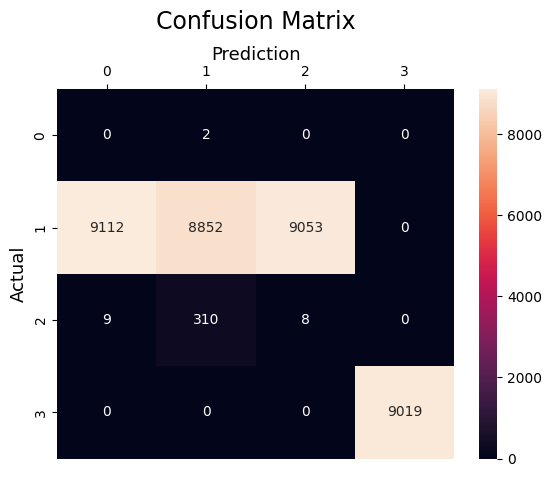

[[   0    2    0    0]
 [9112 8852 9053    0]
 [   9  310    8    0]
 [   0    0    0 9019]]

predictive accuracy: 0.49165406297263853

R*: 1.9666162518905541

=====

Training Model

...

=====

Testing Results!

=====

Number of independent MCMCs: 8

Training Results!

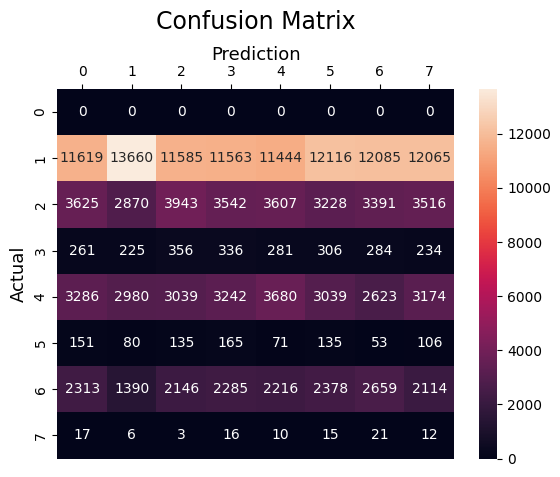

[[    0     0     0     0     0     0     0     0]
 [11619 13660 11585 11563 11444 12116 12085 12065]
 [ 3625  2870  3943  3542  3607  3228  3391  3516]
 [  261   225   356   336   281   306   284   234]
 [ 3286  2980  3039  3242  3680  3039  2623  3174]
 [  151    80   135   165    71   135    53   106]
 [ 2313  1390  2146  2285  2216  2378  2659  2114]
 [   17     6     3    16    10    15    21    12]]

predictive accuracy: 0.14392876925433995

R*: 1.1514301540347196

=====

Testing Results!

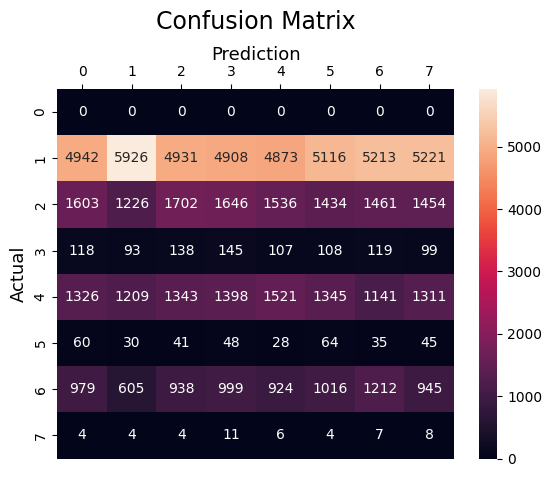

[[   0    0    0    0    0    0    0    0]
 [4942 5926 4931 4908 4873 5116 5213 5221]
 [1603 1226 1702 1646 1536 1434 1461 1454]
 [ 118   93  138  145  107  108  119   99]
 [1326 1209 1343 1398 1521 1345 1141 1311]
 [  60   30   41   48   28   64   35   45]
 [ 979  605  938  999  924 1016 1212  945]
 [   4    4    4   11    6    4    7    8]]

predictive accuracy: 0.1454420459232779

R*: 1.1635363673862231

=====

Training Model

...

Number of independent MCMCs: 8

Training Results!

=====

Testing Results!

=====

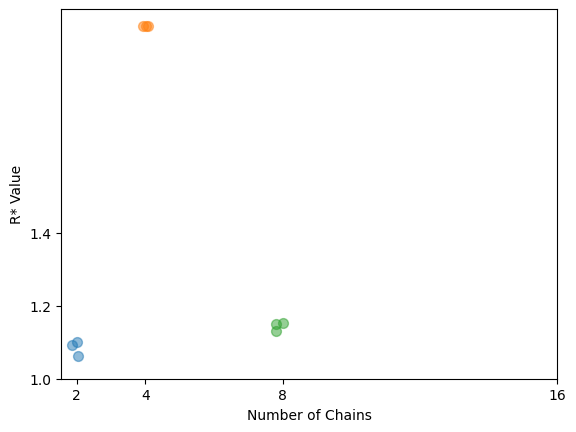

In [ ]:
#maybe make the process in this block a Class??
datapoints = 3

ml_model2.test_model_class(chain_list_2)
list_2 = ml_model2.getRStar_vals(chain_list_2, datapoints)# gets an array of R* values for chain list 2 (chain list 2 has 2 separate .ROOT files, chain 4 has 4 etc...)

ml_model4.test_model_class(chain_list_4)
list_4 = ml_model4.getRStar_vals(chain_list_4, datapoints)

ml_model8.test_model_class(chain_list_8)
list_8 = ml_model8.getRStar_vals(chain_list_8, datapoints)

#ml_model4.test_model_class(chain_list_4)
#list_4 = ml_model4.getRStar_vals(chain_list_4, 3)


def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))

x1 = add_jitter([2.0]*datapoints)
x2= add_jitter([4.0]*datapoints)
x3= add_jitter([8.0]*datapoints)

#x4= [16.00000]*n
plt.scatter(x1,list_2, s=50, cmap= 'twilight', alpha= 0.5)
plt.scatter(x2,list_4, s=50, cmap= 'twilight', alpha= 0.5)
plt.scatter(x3,list_8, s=50, cmap= 'twilight', alpha= 0.5)

plt.xticks([2, 4, 8, 16], ['2', '4', '8', '16'])
plt.yticks([1.0, 1.2, 1.4], ['1.0', '1.2', '1.4'])
plt.title('Sensitivity to number of chains')
plt.xlabel('Number of Chains')
plt.ylabel('R* Value')

#plt.scatter(x3,list_8)
#plt.scatter(x4,list_16)
plt.show()


